In [2]:
import pandas as pd
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score

In [3]:
# Load data
# Download latest version
import kagglehub
path = kagglehub.dataset_download("computingvictor/transactions-fraud-datasets")

print("Path to dataset files:", path)
# Load CSV files
card_data = pd.read_csv("/Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1/cards_data.csv")
transactions = pd.read_csv("/Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1/transactions_data.csv")
users_data = pd.read_csv("/Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1/users_data.csv")
# Load Json files
with open("/Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1/mcc_codes.json", "r") as f:
    mcc_codes = json.load(f)
with open("/Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1/train_fraud_labels.json", "r") as f:
    train_fraud_labels = json.load(f)

Path to dataset files: /Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1


In [4]:
# Assuming mcc_codes is a dictionary where the keys are MCC codes and the values are descriptions
mcc_codes_df = pd.DataFrame(list(mcc_codes.items()), columns=['mcc_code', 'description'])
mcc_codes_df.head()

,mcc_code,description
0,5812,Eating Places and Restaurants
1,5541,Service Stations
2,7996,"Amusement Parks, Carnivals, Circuses"
3,5411,"Grocery Stores, Supermarkets"
4,4784,Tolls and Bridge Fees


In [5]:
# Extracting the nested dictionary from 'target'
transaction_dict = train_fraud_labels['target']

# Creating a DataFrame from the extracted dictionary
fraud_labels_df = pd.DataFrame(list(transaction_dict.items()), columns=['transaction_id', 'true_label'])

# Display the first few rows to verify the structure
print(fraud_labels_df.head())

  transaction_id true_label
0       10649266         No
1       23410063         No
2        9316588         No
3       12478022         No
4        9558530         No


In [6]:
# Data type check and adjust
users_data['per_capita_income'] = users_data['per_capita_income'].replace({'\$': ''}, regex = True).astype(int)
users_data['yearly_income'] = users_data['yearly_income'].replace({'\$': ''}, regex = True).astype(int)
users_data['total_debt'] = users_data['total_debt'].replace({'\$': ''}, regex = True).astype(int)
card_data['expires'] = pd.to_datetime(card_data['expires'], format='%m/%Y')


In [7]:
card_data.dtypes

id                                int64
client_id                         int64
card_brand                       object
card_type                        object
card_number                       int64
expires                  datetime64[ns]
cvv                               int64
has_chip                         object
num_cards_issued                  int64
credit_limit                     object
acct_open_date                   object
year_pin_last_changed             int64
card_on_dark_web                 object
dtype: object

In [8]:
users_data.dtypes

id                     int64
current_age            int64
retirement_age         int64
birth_year             int64
birth_month            int64
gender                object
address               object
latitude             float64
longitude            float64
per_capita_income      int64
yearly_income          int64
total_debt             int64
credit_score           int64
num_credit_cards       int64
dtype: object

In [9]:
transactions.dtypes

id                  int64
date               object
client_id           int64
card_id             int64
amount             object
use_chip           object
merchant_id         int64
merchant_city      object
merchant_state     object
zip               float64
mcc                 int64
errors             object
dtype: object

In [10]:
card_user = pd.merge(card_data, users_data, left_on='client_id', right_on='id', how='left', suffixes=('_card', '_user'))

In [11]:
card_user.dtypes

id_card                           int64
client_id                         int64
card_brand                       object
card_type                        object
card_number                       int64
expires                  datetime64[ns]
cvv                               int64
has_chip                         object
num_cards_issued                  int64
credit_limit                     object
acct_open_date                   object
year_pin_last_changed             int64
card_on_dark_web                 object
id_user                           int64
current_age                       int64
retirement_age                    int64
birth_year                        int64
birth_month                       int64
gender                           object
address                          object
latitude                        float64
longitude                       float64
per_capita_income                 int64
yearly_income                     int64
total_debt                        int64


In [12]:
labels_dict = train_fraud_labels["target"] # Extract the dictionary from JSON
# Map the label using dictionary to transactions data
transactions["label"] = transactions["id"].astype(str).map(labels_dict)
# Test set: where 'label' is NaN
test_set = transactions[transactions['label'].isna()].copy()

# Training set: where 'label' is NOT NaN
train_set = transactions[transactions['label'].notna()].copy()


print('percentage of test: ', round(test_set.shape[0] / (train_set.shape[0] + train_set.shape[0]), 4))

# Display the counts
print(f"Training Set: {train_set.shape[0]} rows")
print(f"Test Set: {test_set.shape[0]} rows")

percentage of test:  0.2463
Training Set: 8914963 rows
Test Set: 4390952 rows


In [13]:
# Group by 'card_id' and count the number of transactions
card_transaction_counts = train_set.groupby('card_id').size().reset_index(name='transaction_count')

# Group by 'card_id' and count the number of 'Yes' labels (anomalies)
card_label_anomalies = train_set[train_set['label'] == 'Yes'].groupby('card_id').size().reset_index(name='label_anormality_count')

# Merge the two DataFrames on 'card_id'
card_transaction_counts = pd.merge(
    card_transaction_counts, 
    card_label_anomalies, 
    on='card_id', 
    how='left'
)

# Fill NaN values in 'label_anormality_count' with 0 (no anomalies for those cards)
card_transaction_counts['label_anormality_count'] = card_transaction_counts['label_anormality_count'].fillna(0).astype(int)
# Calculate the percentage of label_anormality_count per transaction_count
card_transaction_counts['anormality_percentage'] = (
    card_transaction_counts['label_anormality_count'] / card_transaction_counts['transaction_count']
)
card_transaction_counts['anormality_percentage'] = (
    card_transaction_counts['label_anormality_count'] / card_transaction_counts['transaction_count']
)
card_transaction_counts['log_anormality_percentage'] = np.log(card_transaction_counts['anormality_percentage'])

# Sort by transaction count / label_anormality count
card_transaction_counts = card_transaction_counts.sort_values(by='transaction_count', ascending=False).reset_index(drop=True)
card_anormal_transaction_counts = card_transaction_counts.sort_values(by='label_anormality_count', ascending=False).reset_index(drop=True)

# Display the result
print(card_transaction_counts.head())  # Display top cards
print(card_anormal_transaction_counts.head())  # Display top anormal cards
print(card_transaction_counts.tail(10))  # Display bottom cards

   card_id  transaction_count  label_anormality_count  anormality_percentage  \
0     4938              21307                       0               0.000000   
1     3239              20484                       7               0.000342   
2     2408              20448                       1               0.000049   
3     3233              18456                       3               0.000163   
4     3801              17052                       7               0.000411   

   log_anormality_percentage  
0                       -inf  
1                  -7.981489  
2                  -9.925640  
3                  -8.724533  
4                  -7.798113  
   card_id  transaction_count  label_anormality_count  anormality_percentage  \
0     3952               1450                      37               0.025517   
1     3697                465                      34               0.073118   
2      258                987                      29               0.029382   
3     2515   

/Users/m/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


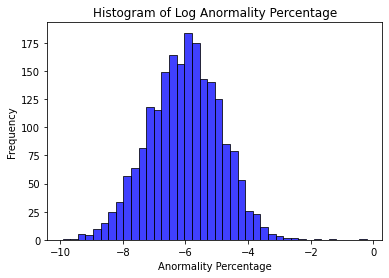

In [14]:
sns.histplot(card_transaction_counts['log_anormality_percentage'], kde=False, color='blue')
plt.title('Histogram of Log Anormality Percentage')
plt.xlabel('Anormality Percentage')
plt.ylabel('Frequency')
plt.show()

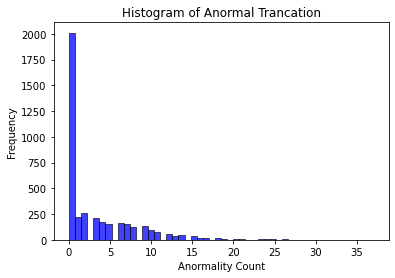

In [15]:
sns.histplot(card_transaction_counts['label_anormality_count'], kde=False, color='blue')
plt.title('Histogram of Anormal Trancation')
plt.xlabel('Anormality Count')
plt.ylabel('Frequency')
plt.show()

In [16]:
merged_df = pd.merge(
    card_user, 
    card_transaction_counts[['card_id', 'label_anormality_count', 'log_anormality_percentage']], 
    left_on='id_card',
    right_on='card_id', 
    how='inner'
)
merged_df = merged_df.drop(['card_id', 'id_user', 'current_age', 'per_capita_income'], axis = 1)

In [17]:
merged_df.columns

Index(['id_card', 'client_id', 'card_brand', 'card_type', 'card_number',
       'expires', 'cvv', 'has_chip', 'num_cards_issued', 'credit_limit',
       'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web',
       'retirement_age', 'birth_year', 'birth_month', 'gender', 'address',
       'latitude', 'longitude', 'yearly_income', 'total_debt', 'credit_score',
       'num_credit_cards', 'label_anormality_count',
       'log_anormality_percentage'],
      dtype='object')

In [18]:
merged_df.shape

(4070, 26)

In [19]:
merged_df.head()

,id_card,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,...,gender,address,latitude,longitude,yearly_income,total_debt,credit_score,num_credit_cards,label_anormality_count,log_anormality_percentage
0,4524,825,Visa,Debit,4344676511950444,2022-12-01,623,YES,2,$24295,...,Female,462 Rose Lane,34.15,-117.76,59696,127613,787,5,7,-5.481829
1,2731,825,Visa,Debit,4956965974959986,2020-12-01,393,YES,2,$21968,...,Female,462 Rose Lane,34.15,-117.76,59696,127613,787,5,0,-inf
2,3701,825,Visa,Debit,4582313478255491,2024-02-01,719,YES,2,$46414,...,Female,462 Rose Lane,34.15,-117.76,59696,127613,787,5,2,-6.682109
3,42,825,Visa,Credit,4879494103069057,2024-08-01,693,NO,1,$12400,...,Female,462 Rose Lane,34.15,-117.76,59696,127613,787,5,1,-8.205218
4,1278,1746,Visa,Debit,4001482973848631,2022-07-01,972,YES,2,$28508,...,Female,3606 Federal Boulevard,40.76,-73.74,77254,191349,701,5,8,-5.009802


In [35]:
clean_df = merged_df.copy()
clean_df = clean_df.drop(columns = ["id_card", "client_id", "card_number", "cvv", "address", "card_on_dark_web", "label_anormality_count"])

# Convert 'credit_limit' from string ($0 format) to numerical
clean_df['credit_limit'] = clean_df['credit_limit'].replace('[\$,]', '', regex=True).astype(float)

# Convert 'acct_open_date' from 'MM/YYYY' to datetime format
clean_df['acct_open_date'] = pd.to_datetime(clean_df['acct_open_date'], format='%m/%Y')

from sklearn.preprocessing import LabelEncoder

# Identify categorical columns (excluding numerical ones)
categorical_columns = clean_df.select_dtypes(include=['object']).columns

# Initialize a dictionary to store encoding mappings
encoding_mappings = {}

# Encode each categorical column
for col in categorical_columns:
    le = LabelEncoder()
    clean_df[col] = le.fit_transform(clean_df[col])  # Encode column
    encoding_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))  # Store mapping

# Print encoding mappings for reference
for col, mapping in encoding_mappings.items():
    print(f"Encoding for {col}: {mapping}")

Encoding for card_brand: {'Amex': 0, 'Discover': 1, 'Mastercard': 2, 'Visa': 3}
Encoding for card_type: {'Credit': 0, 'Debit': 1, 'Debit (Prepaid)': 2}
Encoding for has_chip: {'NO': 0, 'YES': 1}
Encoding for gender: {'Female': 0, 'Male': 1}


In [36]:
clean_df.head()

,card_brand,card_type,expires,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,retirement_age,birth_year,birth_month,gender,latitude,longitude,yearly_income,total_debt,credit_score,num_credit_cards,log_anormality_percentage,high_anomaly
0,3,1,2022-12-01,1,2,24295.0,2002-09-01,2008,66,1966,11,0,34.15,-117.76,59696,127613,787,5,-5.481829,1
1,3,1,2020-12-01,1,2,21968.0,2014-04-01,2014,66,1966,11,0,34.15,-117.76,59696,127613,787,5,-inf,0
2,3,1,2024-02-01,1,2,46414.0,2003-07-01,2004,66,1966,11,0,34.15,-117.76,59696,127613,787,5,-6.682109,0
3,3,0,2024-08-01,0,1,12400.0,2003-01-01,2012,66,1966,11,0,34.15,-117.76,59696,127613,787,5,-8.205218,0
4,3,1,2022-07-01,1,2,28508.0,2011-02-01,2011,68,1966,12,0,40.76,-73.74,77254,191349,701,5,-5.009802,1


/var/folders/3h/c0snmy8116s3hbf_c1nbyb9c0000gn/T/ipykernel_68398/743626698.py:6: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = clean_df.corr()


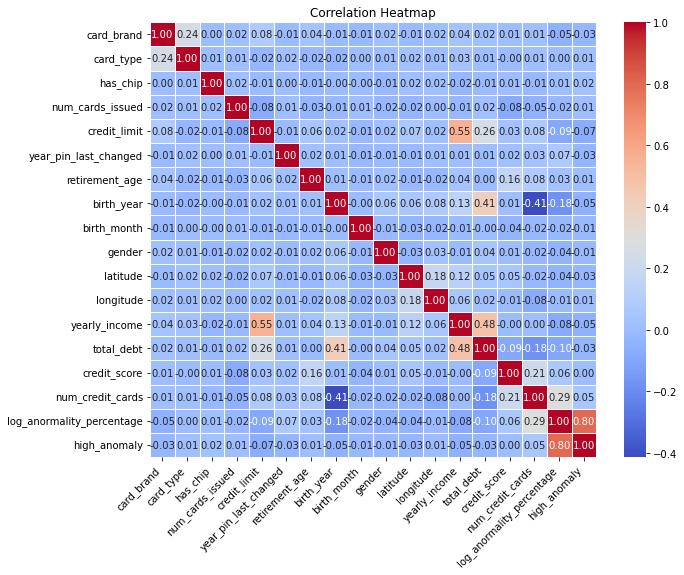

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming merged_df is your DataFrame
# Compute the correlation matrix
corr = clean_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')

# Improve the visibility of the heatmap
plt.xticks(rotation=45, ha='right')  # Rotate the column labels for better readability
plt.yticks(rotation=0)  # Keep the row labels horizontal

plt.show()



In [38]:
# Determine the threshold for high anomaly
threshold = clean_df['log_anormality_percentage'].quantile(0.75)

# Create a binary target variable based on this threshold
clean_df['high_anomaly'] = (clean_df['log_anormality_percentage'] > threshold).astype(int)

# Check the balance
print(clean_df['high_anomaly'].value_counts())

0    3052
1    1018
Name: high_anomaly, dtype: int64


In [39]:
from sklearn.utils import resample

# Separate high and low anomaly samples
high_anomaly = clean_df[clean_df['high_anomaly'] == 1]
low_anomaly = clean_df[clean_df['high_anomaly'] == 0]

# Oversample high anomaly class
high_anomaly_oversampled = resample(high_anomaly,
                                    replace=True,  # Sample with replacement
                                    n_samples=len(low_anomaly),  # Match number in majority class
                                    random_state=42)  # Reproducible results

# Combine the oversampled high anomaly class with the low anomaly class
oversampled_df = pd.concat([low_anomaly, high_anomaly_oversampled])

# Display new class counts
print(oversampled_df['high_anomaly'].value_counts())


0    3052
1    3052
Name: high_anomaly, dtype: int64


In [41]:
# For example, analyzing the oversampled data
oversampled_corr = oversampled_df.corr()
print(oversampled_corr['log_anormality_percentage'].sort_values(ascending=False))

log_anormality_percentage    1.000000
high_anomaly                 0.759165
num_credit_cards             0.259572
year_pin_last_changed        0.060432
credit_score                 0.052062
card_type                    0.018001
retirement_age               0.017602
has_chip                     0.014859
num_cards_issued             0.002824
longitude                   -0.008056
birth_month                 -0.028059
gender                      -0.037547
latitude                    -0.054807
card_brand                  -0.056017
yearly_income               -0.068356
total_debt                  -0.080688
credit_limit                -0.092274
birth_year                  -0.155595
Name: log_anormality_percentage, dtype: float64


/var/folders/3h/c0snmy8116s3hbf_c1nbyb9c0000gn/T/ipykernel_68398/3333108019.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  oversampled_corr = oversampled_df.corr()


/var/folders/3h/c0snmy8116s3hbf_c1nbyb9c0000gn/T/ipykernel_68398/2000035219.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_resampled = oversampled_df.corr()


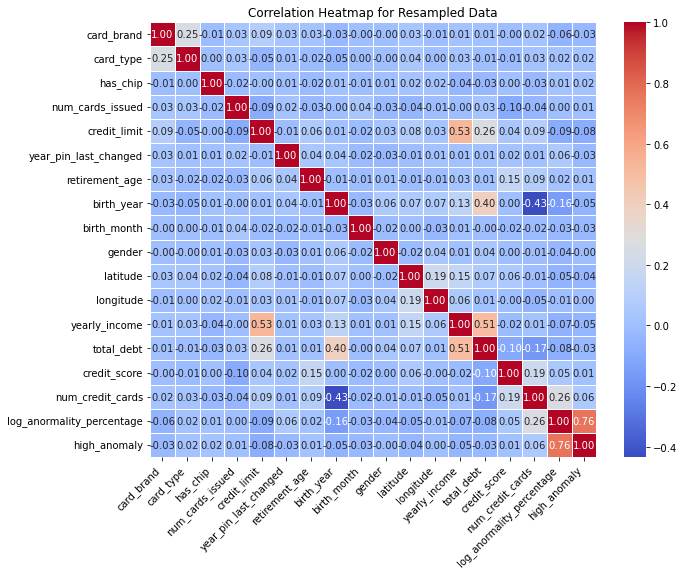

In [42]:
# Compute the correlation matrix
corr_resampled = oversampled_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_resampled, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap for Resampled Data')

# Improve the visibility of the heatmap
plt.xticks(rotation=45, ha='right')  # Rotate the column labels for better readability
plt.yticks(rotation=0)  # Keep the row labels horizontal

plt.show()

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn import tree


# Define target variable (log_anormality_percentage)
target = 'log_anormality_percentage'
clean_df[target] = merged_df['log_anormality_percentage'].replace(-np.inf, np.log(1e-6))

# Select only numerical demographic factors as features
features = clean_df.select_dtypes(include=[np.number]).columns.tolist()
features.remove(target)  # Remove target from features list
features.remove('high_anomaly')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(clean_df[features], clean_df[target], test_size=0.2, random_state=42)


In [62]:
# Initialize Decision Tree Regressor
reg_tree = DecisionTreeRegressor(random_state=42)

# Train the model
reg_tree.fit(X_train, y_train)

# Predict on test data
y_pred = reg_tree.predict(X_test)

# Evaluate Model Performance
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 31.0044


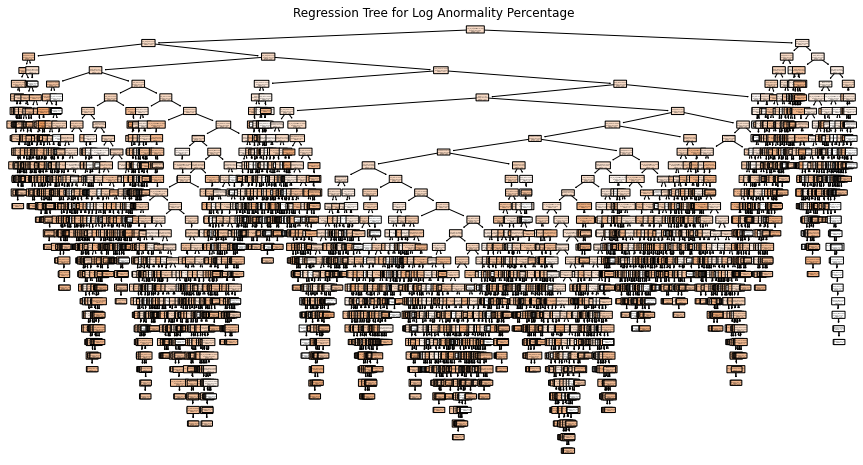

In [63]:
plt.figure(figsize=(15, 8))
tree.plot_tree(reg_tree, feature_names=features, filled=True, rounded=True)
plt.title("Regression Tree for Log Anormality Percentage")
plt.show()


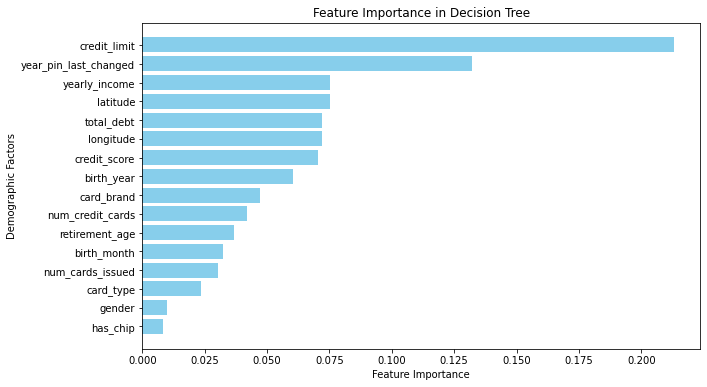

In [64]:
# Extract feature importance
importances = reg_tree.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance")
plt.ylabel("Demographic Factors")
plt.title("Feature Importance in Decision Tree")
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()


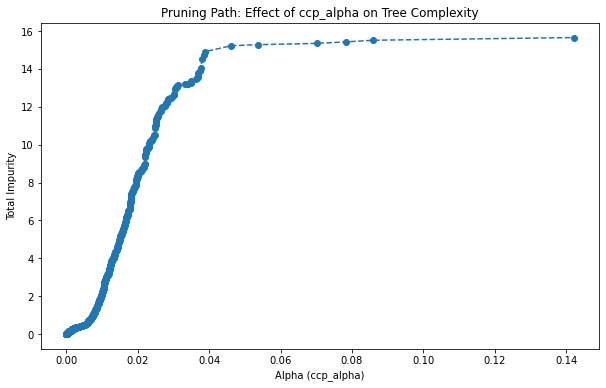

In [65]:
# Pruning the tree
# Train a full tree first
full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)

# Get cost complexity pruning path
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Plot the effect of pruning
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas[:-1], impurities[:-1], marker='o', linestyle='--')
plt.xlabel("Alpha (ccp_alpha)")
plt.ylabel("Total Impurity")
plt.title("Pruning Path: Effect of ccp_alpha on Tree Complexity")
plt.show()


Mean Squared Error: 16.6515


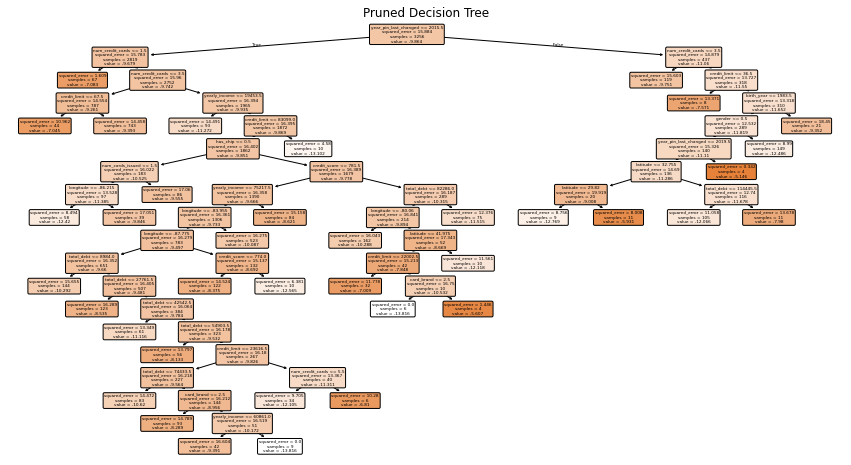

In [67]:
# Choose the best alpha (smallest one before impurity increases significantly)
best_alpha = ccp_alphas[np.argmax(np.diff(impurities))] 

# Train the pruned tree
pruned_tree = DecisionTreeRegressor(ccp_alpha=best_alpha, random_state=42)
pruned_tree.fit(X_train, y_train)

# Predict on test data
y_pred = pruned_tree.predict(X_test)

# Evaluate Model Performance
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")


# Plot the pruned tree
plt.figure(figsize=(15, 8))
from sklearn import tree
tree.plot_tree(pruned_tree, feature_names=X_train.columns, filled=True, rounded=True)
plt.title("Pruned Decision Tree")
plt.show()


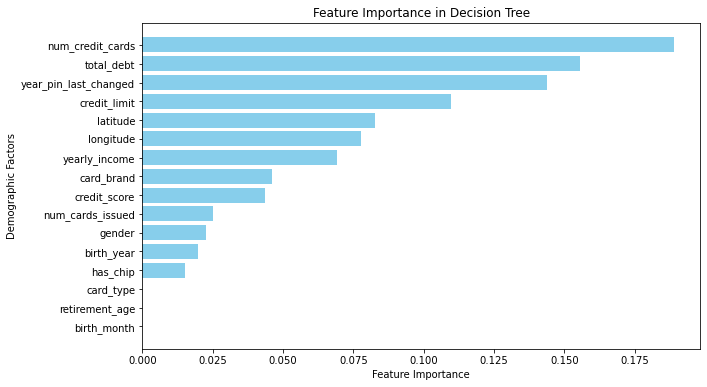

In [69]:
# Extract feature importance
importances = pruned_tree.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance")
plt.ylabel("Demographic Factors")
plt.title("Feature Importance in Decision Tree")
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()